In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#loading dataset
df=pd.read_csv("training_data.csv")
#previewing
df.head()

,fid,VALUE,source_name,source_link,event_id,event_date,event_time,event_title,event_description,location_description,...,SAMPLE_aspect1,SAMPLE_flow1,SAMPLE_road1,SAMPLE_river1,SAMPLE_LC1,SAMPLE_LC1_2,x,y,SAMPLE_rainfall1,SAMPLE_rainfall2
0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,53.615646,1.706507e+03,8503.557617,618.465820,7,305.688141,404580.030639,3.034051e+06,305.688141,255
1,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.492592,3.327688e+04,5717.735352,853.287720,4,285.050293,372331.638589,3.034840e+06,285.050293,255
2,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,248.962494,1.221432e+07,2440.348389,42.426407,7,312.853180,392720.567621,3.034518e+06,312.853180,255
3,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,243.208481,8.532533e+02,7120.372070,597.745728,4,294.876434,370725.061087,3.034606e+06,294.876434,255
4,5,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.579227,1.706507e+03,5304.658203,632.850647,7,313.960663,398153.720629,3.034693e+06,313.960663,255


In [3]:
#  checking for null values
df.isna().sum()

fid                            0
VALUE                          0
source_name                  290
source_link                  291
event_id                     290
event_date                   290
event_time                   300
event_title                  290
event_description            290
location_description         290
location_accuracy            290
landslide_category           290
landslide_trigger            290
landslide_size               290
landslide_setting            290
fatality_count               292
injury_count                 295
storm_name                   300
photo_link                   299
notes                        300
event_import_source          292
event_import_id              292
country_name                 292
country_code                 292
admin_division_name          292
admin_division_population    292
gazeteer_closest_point       292
gazeteer_distance            292
submitted_date               290
created_date                 290
last_edite

In [4]:
# only selecting required columns
df_clean = df[
    [
        'SAMPLE_slope1',
        'SAMPLE_aspect1',
        'SAMPLE_SPI1',
        'SAMPLE_flow1',
        'SAMPLE_road1',
        'SAMPLE_river1',
        'SAMPLE_LC1', 'SAMPLE_LC1_2',
        'SAMPLE_rainfall1',
        'VALUE'
    ]
]

In [5]:
# previewing
df_clean.head()

,SAMPLE_slope1,SAMPLE_aspect1,SAMPLE_SPI1,SAMPLE_flow1,SAMPLE_road1,SAMPLE_river1,SAMPLE_LC1,SAMPLE_LC1_2,SAMPLE_rainfall1,VALUE
0,21.997665,53.615646,3.753916e+04,1.706507e+03,8503.557617,618.465820,7,305.688141,305.688141,0
1,24.335804,20.492592,8.098196e+05,3.327688e+04,5717.735352,853.287720,4,285.050293,285.050293,0
2,13.409784,248.962494,1.637914e+08,1.221432e+07,2440.348389,42.426407,7,312.853180,312.853180,0
3,25.835497,243.208481,2.204422e+04,8.532533e+02,7120.372070,597.745728,4,294.876434,294.876434,0
4,23.624996,30.579227,4.031621e+04,1.706507e+03,5304.658203,632.850647,7,313.960663,313.960663,0


In [6]:
# again checking for null values
df_clean.isna().sum()

SAMPLE_slope1       0
SAMPLE_aspect1      0
SAMPLE_SPI1         0
SAMPLE_flow1        0
SAMPLE_road1        0
SAMPLE_river1       0
SAMPLE_LC1          0
SAMPLE_LC1_2        0
SAMPLE_rainfall1    0
VALUE               0
dtype: int64

In [7]:
#checking the length of dataset
len(df_clean)

300

In [8]:
#landslide status balance check
df_clean['VALUE'].value_counts()

VALUE
0    150
1    150
Name: count, dtype: int64

In [9]:
# separating feature and target variables
X=df_clean.drop("VALUE",axis=1)
y=df_clean['VALUE']

In [10]:
# creating spatial groups

df['lat_group'] = pd.cut(df['y'], bins=3, labels=False)
df['lon_group'] = pd.cut(df['x'], bins=3, labels=False)
df['spatial_group'] = df['lat_group'] * 3 + df['lon_group']

groups = df['spatial_group']

print("\n Spatial Group Distribution:  ")
print(groups.value_counts().sort_index())
print(f"Total unique groups: {groups.nunique()}")


 Spatial Group Distribution:  
spatial_group
1    27
2    25
3     2
4    47
5    83
6    66
7    45
8     5
Name: count, dtype: int64
Total unique groups: 8


In [11]:
# defining the models we will be using here

from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
import seaborn as sns


models = {
    'Logistic Regression': LogisticRegression(
        C=0.1,
        max_iter=1000
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        eval_metric='logloss',
        random_state=42
    )
}

In [12]:
# spatial cross validation
gkf = GroupKFold(n_splits=5)

print("Spatial Cross Validation Results \n")

results = {}

for name, model in models.items():
    # AUC scores
    auc_scores = cross_val_score(
        model, X, y,
        cv=gkf.split(X, y, groups=groups),
        scoring='roc_auc'
    )
    
    # Accuracy scores
    acc_scores = cross_val_score(
        model, X, y,
        cv=gkf.split(X, y, groups=groups),
        scoring='accuracy'
    )
    
    # F1 scores
    f1_scores = cross_val_score(
        model, X, y,
        cv=gkf.split(X, y, groups=groups),
        scoring='f1'
    )
    
    # Precision scores
    precision_scores = cross_val_score(
        model, X, y,
        cv=gkf.split(X, y, groups=groups),
        scoring='precision'
    )
    
    # Recall scores
    recall_scores = cross_val_score(
        model, X, y,
        cv=gkf.split(X, y, groups=groups),
        scoring='recall'
    )
    
    # Storing results
    results[name] = {
        'AUC': auc_scores.mean(),
        'Accuracy': acc_scores.mean(),
        'F1': f1_scores.mean(),
        'Precision': precision_scores.mean(),
        'Recall': recall_scores.mean()
    }
    
    # displaying results
    print(f"{name}:")
    print(f"  AUC:       {auc_scores.mean():.4f} (+/- {auc_scores.std():.4f})")
    print(f"  Accuracy:  {acc_scores.mean():.4f} (+/- {acc_scores.std():.4f})")
    print(f"  F1:        {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f})")
    print(f"  Precision: {precision_scores.mean():.4f} (+/- {precision_scores.std():.4f})")
    print(f"  Recall:    {recall_scores.mean():.4f} (+/- {recall_scores.std():.4f})")
    print()

Spatial Cross Validation Results 



C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i 

Logistic Regression:
  AUC:       0.9740 (+/- 0.0253)
  Accuracy:  0.9227 (+/- 0.0398)
  F1:        0.9229 (+/- 0.0239)
  Precision: 0.9130 (+/- 0.0494)
  Recall:    0.9378 (+/- 0.0552)

Decision Tree:
  AUC:       0.9755 (+/- 0.0316)
  Accuracy:  0.9716 (+/- 0.0383)
  F1:        0.9741 (+/- 0.0338)
  Precision: 0.9913 (+/- 0.0174)
  Recall:    0.9584 (+/- 0.0520)

Gradient Boosting:
  AUC:       0.9767 (+/- 0.0285)
  Accuracy:  0.9676 (+/- 0.0361)
  F1:        0.9709 (+/- 0.0319)
  Precision: 0.9851 (+/- 0.0187)
  Recall:    0.9584 (+/- 0.0520)

XGBoost:
  AUC:       0.9778 (+/- 0.0228)
  Accuracy:  0.9724 (+/- 0.0279)
  F1:        0.9744 (+/- 0.0255)
  Precision: 1.0000 (+/- 0.0000)
  Recall:    0.9512 (+/- 0.0481)



In [13]:
# comparing the models 
results_df = pd.DataFrame(results).T
print(results_df.round(4))


                        AUC  Accuracy      F1  Precision  Recall
Logistic Regression  0.9740    0.9227  0.9229     0.9130  0.9378
Decision Tree        0.9755    0.9716  0.9741     0.9913  0.9584
Gradient Boosting    0.9767    0.9676  0.9709     0.9851  0.9584
XGBoost              0.9778    0.9724  0.9744     1.0000  0.9512


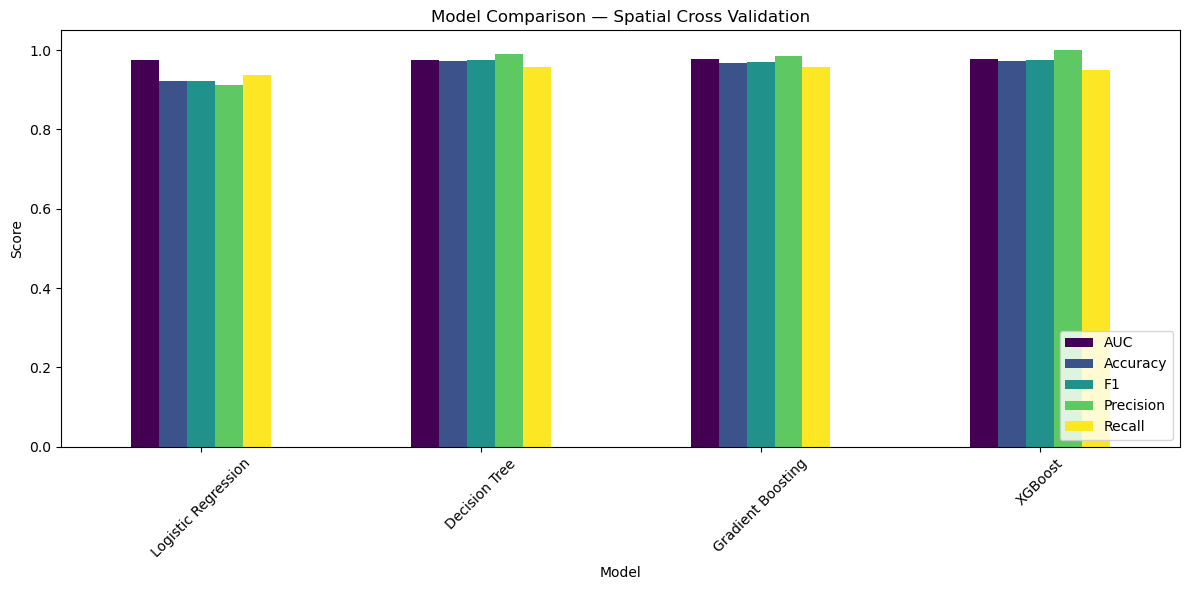

In [14]:
# model comparison visualization
results_df.plot(
    kind='bar',
    figsize=(12, 6),
    colormap='viridis'
)
plt.title('Model Comparison — Spatial Cross Validation')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [15]:
# confusion matrix for best model and training best model on full data
# data split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # ensures balanced split
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# defining final xgboost model
final_model = XGBClassifier(
    n_estimators=200,       # more trees for better learning
    max_depth=3,            # shallow trees — prevents overfitting
    learning_rate=0.05,     # slow learning — more accurate
    subsample=0.8,          # use 80% of data per tree
    colsample_bytree=0.8,   # use 80% of features per tree
    reg_alpha=0.1,          # L1 regularization
    reg_lambda=1.0,         # L2 regularization
    eval_metric='logloss',
    random_state=42
)

#training
final_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

Training samples: 240
Testing samples:  60


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [16]:
#evaulating the model
y_pred = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

#calculating the metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_pred_proba)

print("Final XGBoost Test Results/n")
print(f"  AUC:       {auc:.4f}")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  F1:        {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")


Final XGBoost Test Results/n
  AUC:       0.9844
  Accuracy:  0.9833
  F1:        0.9831
  Precision: 1.0000
  Recall:    0.9667


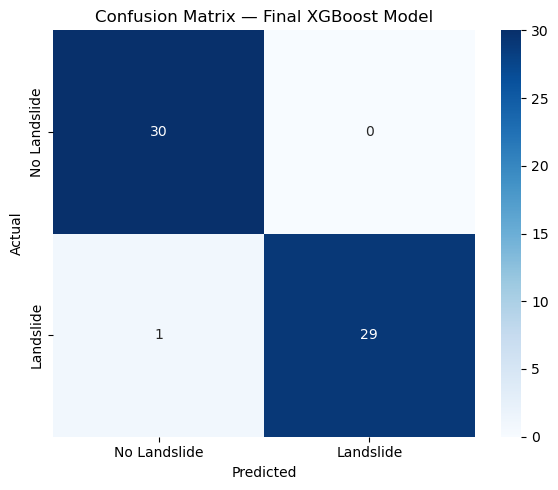

In [17]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Landslide', 'Landslide'],
    yticklabels=['No Landslide', 'Landslide']
)
plt.title('Confusion Matrix — Final XGBoost Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

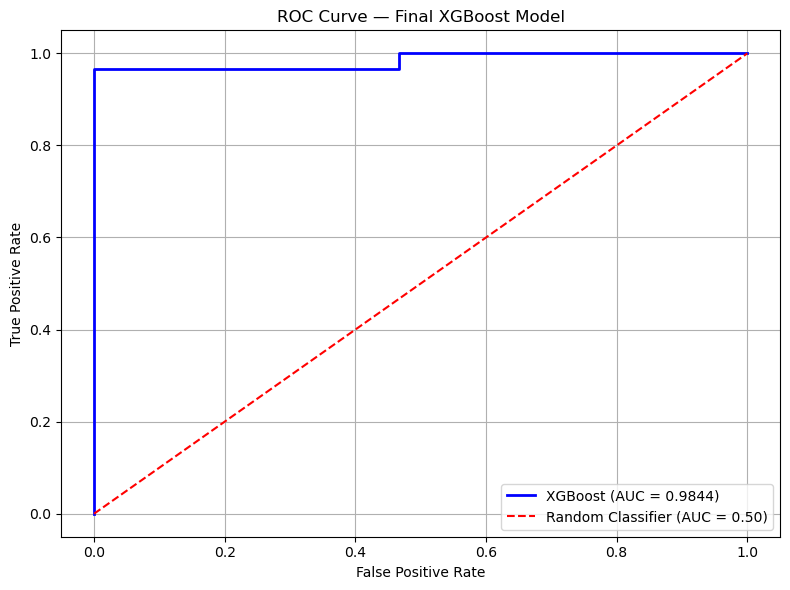

In [18]:
#ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr, tpr,
    color='blue',
    linewidth=2,
    label=f'XGBoost (AUC = {auc:.4f})'
)
plt.plot(
    [0, 1], [0, 1],
    color='red',
    linestyle='--',
    label='Random Classifier (AUC = 0.50)'
)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Final XGBoost Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

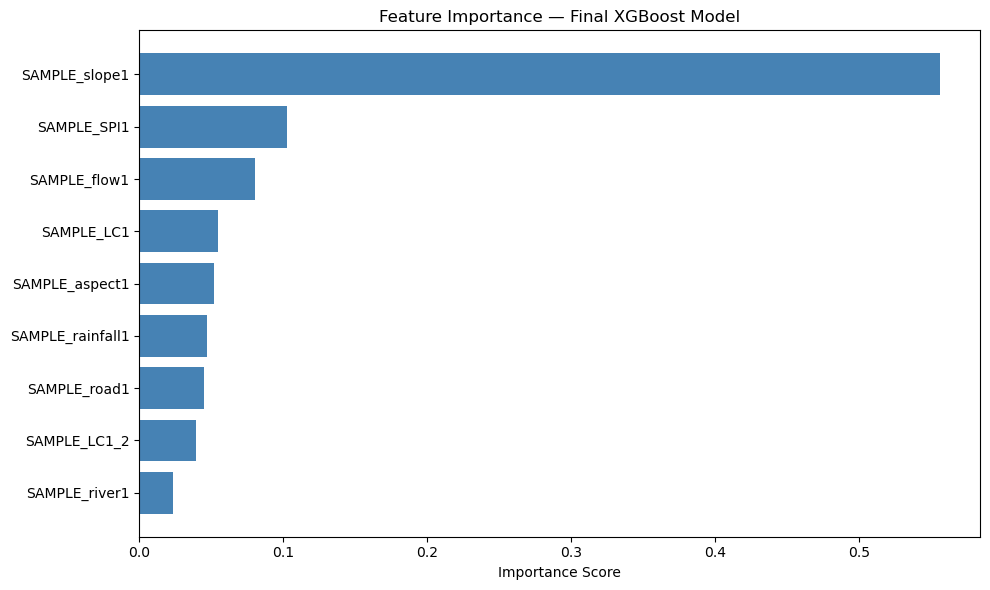

Feature Importance Ranking

         Feature  Importance
   SAMPLE_slope1    0.556464
     SAMPLE_SPI1    0.102716
    SAMPLE_flow1    0.080649
      SAMPLE_LC1    0.054919
  SAMPLE_aspect1    0.051550
SAMPLE_rainfall1    0.046780
    SAMPLE_road1    0.044555
    SAMPLE_LC1_2    0.039107
   SAMPLE_river1    0.023261


In [19]:
# feature importance
feature_cols = [
    'SAMPLE_slope1',
    'SAMPLE_aspect1',
    'SAMPLE_SPI1',
    'SAMPLE_flow1',
    'SAMPLE_road1',
    'SAMPLE_river1',
    'SAMPLE_LC1',
    'SAMPLE_LC1_2',
    'SAMPLE_rainfall1'
]

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color='steelblue'
)
plt.title('Feature Importance — Final XGBoost Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Feature Importance Ranking\n")
print(importance_df.sort_values(
    'Importance',
    ascending=False
).to_string(index=False))

In [20]:
# saving the model
import joblib

joblib.dump(final_model, 'xgboost_landslide_model.pkl')
print(" Model saved as xgboost_landslide_model.pkl")

 Model saved as xgboost_landslide_model.pkl


In [40]:
# landslide susceptibility Map Generation
import numpy as np
import rasterio
from rasterio.transform import from_bounds
import joblib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import warnings
from rasterio.enums import Resampling
warnings.filterwarnings('ignore')

In [22]:
#loading the model
model=joblib.load("xgboost_landslide_model.pkl")

In [23]:
# raster files
raster_files = {
    'slope'    : 'slope_dem.tif',
    'aspect'   : 'aspect.tif',
    'SPI'      : 'SPI.tif',
    'flow'     : 'flow_accum.tif',
    'road'     : 'proximity_distance.tiff',
    'river'    : 'river_distance.tiff',
    'rainfall' : 'rainfall_mean.tif'
}

landcover_file = 'LC_clipped.tiff'

In [24]:
# reading reference raster metadata
with rasterio.open(raster_files['slope']) as ref:
    reference_meta = ref.meta.copy()
    reference_transform = ref.transform
    reference_crs = ref.crs
    height = ref.height
    width = ref.width
    nodata = ref.nodata

print(f" Reference raster loaded")
print(f"   Shape: {height} x {width}")
print(f"   CRS: {reference_crs}")
print(f"   NoData: {nodata}")

 Reference raster loaded
   Shape: 3088 x 2220
   CRS: EPSG:32645
   NoData: -9999.0


In [36]:
#resampling rasters

def read_and_resample(filepath, band=1, nodata_val=None):
    with rasterio.open(filepath) as src:
        if src.height != height or src.width != width:
            print(f"    Resampling {filepath}")
            print(f"      From: {src.height} x {src.width} → To: {height} x {width}")
            data = src.read(
                band,
                out_shape  = (height, width),
                resampling = Resampling.bilinear
            ).astype(np.float32)
        else:
            data = src.read(band).astype(np.float32)

    # Replace nodata with nan
    if nodata_val is not None:
        data[data == nodata_val] = np.nan

    # Replace extremely large or small values
    data[data > 1e+37]  = np.nan
    data[data < -1e+10] = np.nan

    print(f"    {filepath} — Band {band}")
    print(f"      Shape: {data.shape}")
    print(f"      Min: {np.nanmin(data):.4f}  Max: {np.nanmax(data):.4f}")
    print(f"      NaN count: {np.isnan(data).sum():,}")
    return data

print(" Resample function defined")

 Resample function defined


In [42]:
# loading all rasters

#defining nodata values for each raster
nodata_values = {
    'slope'    : -9999.0,
    'aspect'   : -9999.0,
    'SPI'      : -3.4028234663852886e+38,
    'flow'     : -99999.0,
    'road'     : None,
    'river'    : None,
    'rainfall' : -3.4028234663852886e+38
}

print(" Loading all rasters...\n")

bands = {}

# Loading single band rasters
for name, file in raster_files.items():
    print(f"Loading {name}...")
    bands[name] = read_and_resample(
        file,
        band       = 1,
        nodata_val = nodata_values[name]
    )
    print()

# Loading landcover Band 1 and Band 2
print("Loading landcover Band 1...")
bands['LC1']   = read_and_resample(landcover_file, band=1, nodata_val=None)
print()
print("Loading landcover Band 2...")
bands['LC1_2'] = read_and_resample(landcover_file, band=2, nodata_val=None)

print("\n All rasters loaded!")

 Loading all rasters...

Loading slope...
    slope_dem.tif — Band 1
      Shape: (3088, 2220)
      Min: 0.0000  Max: 72.4129
      NaN count: 4,019,166

Loading aspect...
    aspect.tif — Band 1
      Shape: (3088, 2220)
      Min: 0.0000  Max: 359.8639
      NaN count: 4,024,177

Loading SPI...
    SPI.tif — Band 1
      Shape: (3088, 2220)
      Min: 0.0000  Max: 14628158464.0000
      NaN count: 4,019,166

Loading flow...
    flow_accum.tif — Band 1
      Shape: (3088, 2220)
      Min: 853.2533  Max: 834572160.0000
      NaN count: 3,990,288

Loading road...
    Resampling proximity_distance.tiff
      From: 3008 x 2161 → To: 3088 x 2220
    proximity_distance.tiff — Band 1
      Shape: (3088, 2220)
      Min: 0.0000  Max: 10005.8037
      NaN count: 0

Loading river...
    Resampling river_distance.tiff
      From: 3008 x 2161 → To: 3088 x 2220
    river_distance.tiff — Band 1
      Shape: (3088, 2220)
      Min: 0.0000  Max: 3662.3921
      NaN count: 0

Loading rainfall...
    

In [44]:
# verifying shapes
all_match = True
for name, band in bands.items():
    match = "matched" if band.shape == (height, width) else "unmatched"
    if band.shape != (height, width):
        all_match = False
    print(f"  {match} {name}: {band.shape}")

if all_match:
    print("\n All shapes matched, ready for prediction!")
else:
    print("\n Shape mismatch detected!")
    raise ValueError("Fix shape mismatch before continuing!")

  matched slope: (3088, 2220)
  matched aspect: (3088, 2220)
  matched SPI: (3088, 2220)
  matched flow: (3088, 2220)
  matched road: (3088, 2220)
  matched river: (3088, 2220)
  matched rainfall: (3088, 2220)
  matched LC1: (3088, 2220)
  matched LC1_2: (3088, 2220)

 All shapes matched, ready for prediction!


In [46]:
# creating valid mask

valid_mask = np.ones((height, width), dtype=bool)

for name, band in bands.items():
    before     = valid_mask.sum()
    valid_mask &= ~np.isnan(band)
    after      = valid_mask.sum()
    print(f"   {name}: removed {before - after:,} invalid pixels")

print(f"\n   Total valid pixels: {valid_mask.sum():,}")
print(f"   Total pixels:       {height * width:,}")
print(f"   Coverage:           {valid_mask.sum() / (height * width) * 100:.1f}%")

   slope: removed 4,019,166 invalid pixels
   aspect: removed 5,011 invalid pixels
   SPI: removed 0 invalid pixels
   flow: removed 0 invalid pixels
   road: removed 0 invalid pixels
   river: removed 0 invalid pixels
   rainfall: removed 0 invalid pixels
   LC1: removed 0 invalid pixels
   LC1_2: removed 0 invalid pixels

   Total valid pixels: 2,831,183
   Total pixels:       6,855,360
   Coverage:           41.3%


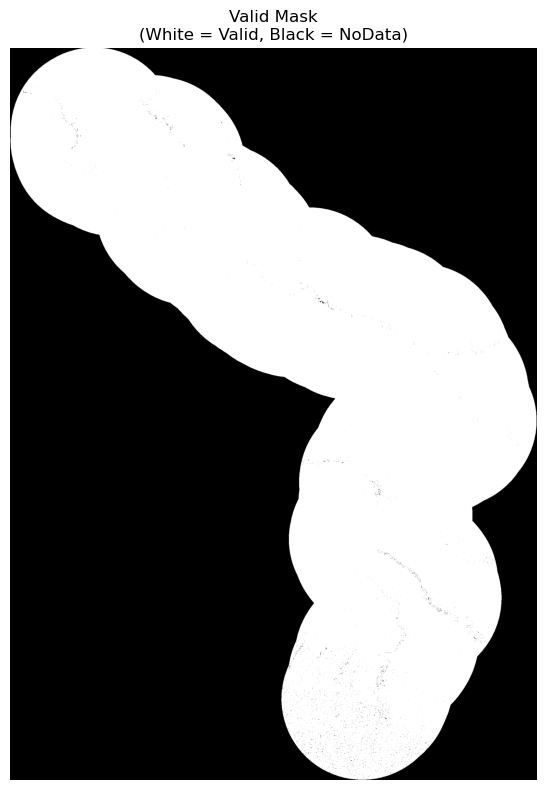

In [48]:
# visualizing valid mask
plt.figure(figsize=(6, 8))
plt.imshow(valid_mask, cmap='gray')
plt.title('Valid Mask\n(White = Valid, Black = NoData)')
plt.axis('off')
plt.tight_layout()
plt.show()

In [50]:
# stacking bands
# CRITICAL: Must match training feature order exactly
# slope, aspect, SPI, flow, road, river, LC1, LC1_2, rainfall
feature_stack = np.stack([
    bands['slope'],
    bands['aspect'],
    bands['SPI'],
    bands['flow'],
    bands['road'],
    bands['river'],
    bands['LC1'],
    bands['LC1_2'],
    bands['rainfall']
], axis=-1)

print(f" Stack shape: {feature_stack.shape}")
print(f"   Height:   {feature_stack.shape[0]}")
print(f"   Width:    {feature_stack.shape[1]}")
print(f"   Features: {feature_stack.shape[2]} (should be 9)")

 Stack shape: (3088, 2220, 9)
   Height:   3088
   Width:    2220
   Features: 9 (should be 9)


In [52]:
#extracting valid pixels
valid_pixels = feature_stack[valid_mask]
valid_pixels = np.nan_to_num(valid_pixels, nan=0.0)

print(f" Valid pixels shape: {valid_pixels.shape}")
print(f"   Rows (pixels):    {valid_pixels.shape[0]:,}")
print(f"   Columns (features): {valid_pixels.shape[1]}")

 Valid pixels shape: (2831183, 9)
   Rows (pixels):    2,831,183
   Columns (features): 9


In [54]:
# predicting susceptibility
susceptibility_proba = model.predict_proba(valid_pixels)[:, 1]

print(f" Predictions complete!")
print(f"   Total predictions: {len(susceptibility_proba):,}")
print(f"   Min:  {susceptibility_proba.min():.4f}")
print(f"   Max:  {susceptibility_proba.max():.4f}")
print(f"   Mean: {susceptibility_proba.mean():.4f}")

 Predictions complete!
   Total predictions: 2,831,183
   Min:  0.0040
   Max:  0.9980
   Mean: 0.3547


In [56]:
#reshaping predictions to raster

susceptibility_map= np.full(
    (height, width),
    fill_value = np.nan,
    dtype      = np.float32
)
susceptibility_map[valid_mask] = susceptibility_proba

print(f" Susceptibility map shape: {susceptibility_map.shape}")
print(f"   Valid cells:   {(~np.isnan(susceptibility_map)).sum():,}")
print(f"   Invalid cells: {np.isnan(susceptibility_map).sum():,}")

 Susceptibility map shape: (3088, 2220)
   Valid cells:   2,831,183
   Invalid cells: 4,024,177


In [58]:
# saving continous susceptibility map

save_map                     = susceptibility_map.copy()
save_map[np.isnan(save_map)] = -9999

output_meta = reference_meta.copy()
output_meta.update({
    'dtype'  : 'float32',
    'count'  : 1,
    'nodata' : -9999
})

with rasterio.open(
    'landslide_susceptibility.tif',
    'w',
    **output_meta
) as dst:
    dst.write(save_map, 1)

print(" Saved: landslide_susceptibility.tif")

 Saved: landslide_susceptibility.tif


In [60]:
# classifyinginto 5 zones

classified_map = np.zeros((height, width), dtype=np.uint8)

classified_map[
    valid_mask &
    (susceptibility_map >= 0.0) &
    (susceptibility_map <  0.2)
] = 1

classified_map[
    valid_mask &
    (susceptibility_map >= 0.2) &
    (susceptibility_map <  0.4)
] = 2

classified_map[
    valid_mask &
    (susceptibility_map >= 0.4) &
    (susceptibility_map <  0.6)
] = 3

classified_map[
    valid_mask &
    (susceptibility_map >= 0.6) &
    (susceptibility_map <  0.8)
] = 4

classified_map[
    valid_mask &
    (susceptibility_map >= 0.8) &
    (susceptibility_map <= 1.0)
] = 5

# Print distribution
zones = {
    1 : 'Very Low',
    2 : 'Low',
    3 : 'Moderate',
    4 : 'High',
    5 : 'Very High'
}

print("=== Zone Distribution ===\n")
for zone_id, zone_name in zones.items():
    count      = (classified_map == zone_id).sum()
    percentage = count / valid_mask.sum() * 100
    print(f"   {zone_name:10}: {count:>10,} pixels ({percentage:5.1f}%)")

# Save
classified_meta = reference_meta.copy()
classified_meta.update({
    'dtype'  : 'uint8',
    'count'  : 1,
    'nodata' : 0
})

with rasterio.open(
    'landslide_susceptibility_classified.tif',
    'w',
    **classified_meta
) as dst:
    dst.write(classified_map, 1)

print(" Saved: landslide_susceptibility_classified.tif")

=== Zone Distribution ===

   Very Low  :  1,761,133 pixels ( 62.2%)
   Low       :    164,658 pixels (  5.8%)
   Moderate  :     41,955 pixels (  1.5%)
   High      :     17,073 pixels (  0.6%)
   Very High :    846,364 pixels ( 29.9%)
 Saved: landslide_susceptibility_classified.tif


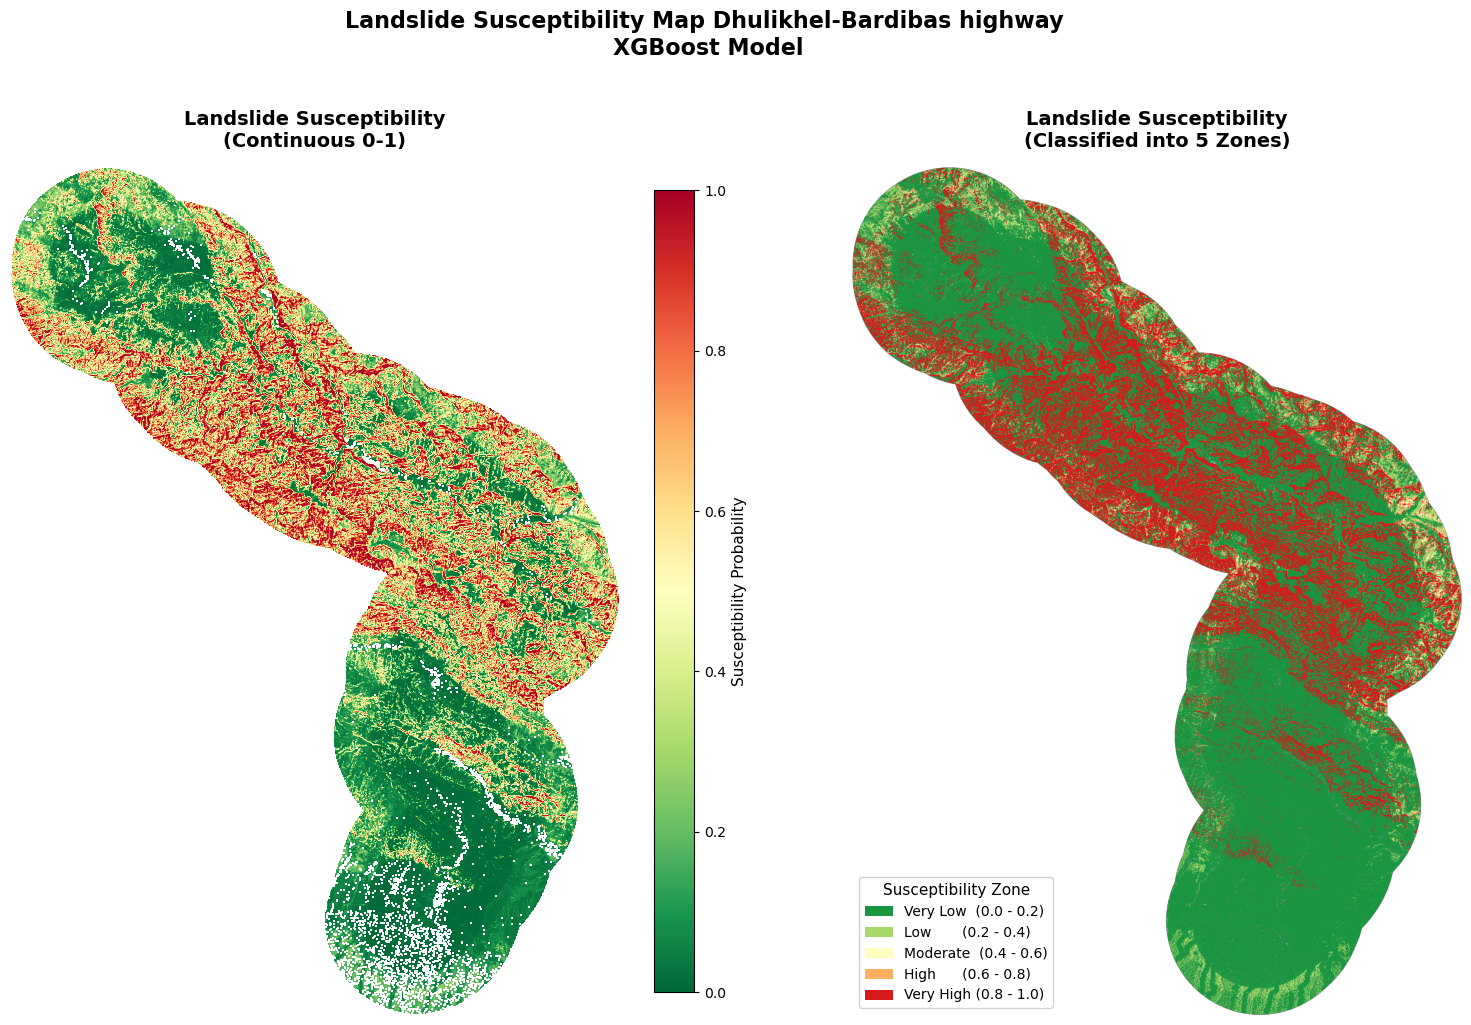

 Final map saved as: susceptibility_map_final.png


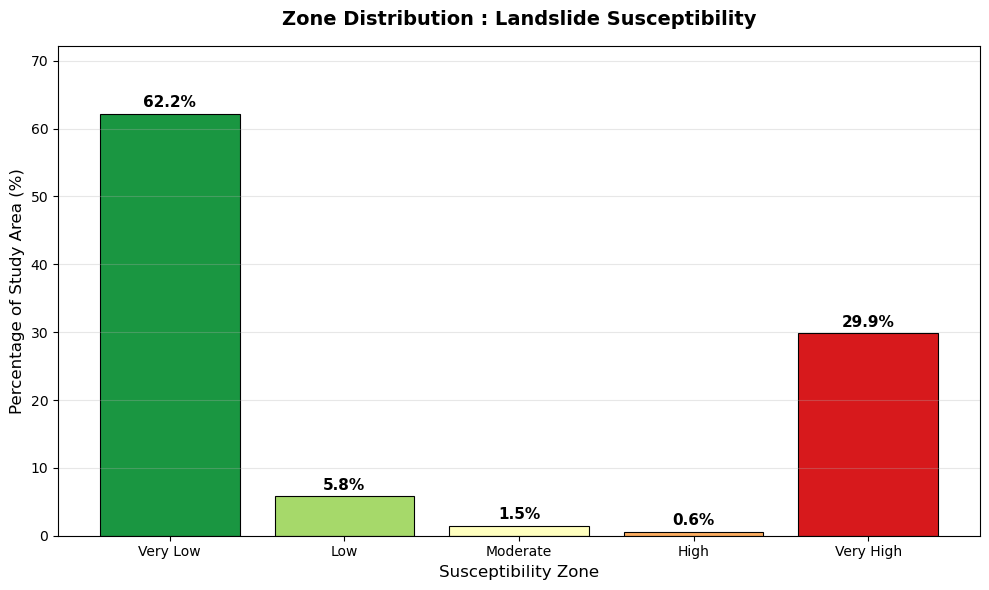

 Zone distribution saved as: zone_distribution.png


In [68]:
# PLOT 1 — CONTINUOUS MAP
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Continuous susceptibility
display_continuous              = susceptibility_map.copy()
display_continuous[~valid_mask] = np.nan

im1 = axes[0].imshow(
    display_continuous,
    cmap = 'RdYlGn_r',
    vmin = 0,
    vmax = 1
)
axes[0].set_title(
    'Landslide Susceptibility\n(Continuous 0-1)',
    fontsize   = 14,
    fontweight = 'bold',
    pad        = 15
)
axes[0].axis('off')
cbar1 = plt.colorbar(
    im1,
    ax       = axes[0],
    fraction = 0.046,
    pad      = 0.04
)
cbar1.set_label('Susceptibility Probability', fontsize=11)
cbar1.ax.tick_params(labelsize=10)


# PLOT 2 — CLASSIFIED MAP WITH PROPER COLORS

# Defining exact colors for each zone
color_map = {
    0 : (0, 0, 0, 0),          # transparent — nodata
    1 : (26, 150, 65, 255),     # dark green   — very low
    2 : (166, 217, 106, 255),   # light green  — low
    3 : (255, 255, 191, 255),   # yellow       — moderate
    4 : (253, 174, 97, 255),    # orange       — high
    5 : (215, 25, 28, 255),     # red          — very high
}

# Creating RGBA image manually
rgba_image = np.zeros(
    (height, width, 4),
    dtype = np.uint8
)

for zone_id, color in color_map.items():
    mask              = classified_map == zone_id
    rgba_image[mask]  = color

# Making nodata transparent
rgba_image[~valid_mask] = [0, 0, 0, 0]

axes[1].imshow(rgba_image)
axes[1].set_title(
    'Landslide Susceptibility\n(Classified into 5 Zones)',
    fontsize   = 14,
    fontweight = 'bold',
    pad        = 15
)
axes[1].axis('off')

# Adding manual legend
legend_elements = [
    mpatches.Patch(facecolor='#1a9641', label='Very Low  (0.0 - 0.2)'),
    mpatches.Patch(facecolor='#a6d96a', label='Low       (0.2 - 0.4)'),
    mpatches.Patch(facecolor='#ffffbf', label='Moderate  (0.4 - 0.6)'),
    mpatches.Patch(facecolor='#fdae61', label='High      (0.6 - 0.8)'),
    mpatches.Patch(facecolor='#d7191c', label='Very High (0.8 - 1.0)'),
]

axes[1].legend(
    handles        = legend_elements,
    loc            = 'lower left',
    fontsize       = 10,
    title          = 'Susceptibility Zone',
    title_fontsize = 11,
    framealpha     = 0.9
)

plt.suptitle(
    'Landslide Susceptibility Map Dhulikhel-Bardibas highway \nXGBoost Model',
    fontsize   = 16,
    fontweight = 'bold',
    y          = 1.02
)

plt.tight_layout()
plt.savefig(
    'susceptibility_map_final.png',
    dpi         = 300,
    bbox_inches = 'tight',
    facecolor   = 'white'
)
plt.show()

print(" Final map saved as: susceptibility_map_final.png")


# PLOT 3 — ZONE DISTRIBUTION BAR CHART

zones       = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']
counts      = [(classified_map == i).sum() for i in range(1, 6)]
percentages = [c / valid_mask.sum() * 100 for c in counts]
colors_bar  = ['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c']

fig2, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    zones,
    percentages,
    color     = colors_bar,
    edgecolor = 'black',
    linewidth = 0.8
)

# Adding percentage labels on bars
for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{pct:.1f}%',
        ha        = 'center',
        va        = 'bottom',
        fontsize  = 11,
        fontweight = 'bold'
    )

ax.set_title(
    'Zone Distribution : Landslide Susceptibility',
    fontsize   = 14,
    fontweight = 'bold',
    pad        = 15
)
ax.set_xlabel('Susceptibility Zone', fontsize=12)
ax.set_ylabel('Percentage of Study Area (%)', fontsize=12)
ax.set_ylim(0, max(percentages) + 10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(
    'zone_distribution.png',
    dpi         = 300,
    bbox_inches = 'tight',
    facecolor   = 'white'
)
plt.show()

print(" Zone distribution saved as: zone_distribution.png")